<a href="https://colab.research.google.com/github/paidasahithi26/NLP_Assignments02/blob/main/Paida_S_hithi_Assignment_04).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer  # Faster than Lemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC     # MUCH faster than SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score

nltk.download('stopwords')

# =========================
# 2. LOAD DATASET
# =========================
from google.colab import files
uploaded = files.upload() # Uncomment if running fresh

# Using a try-except block for easier local/Colab switching
try:
    df = pd.read_csv("archive (3).zip", compression='zip')
except:
    print("Ensure the file 'archive (3).zip' is uploaded to the environment.")

# =========================
# 3. LABEL ENCODING & PREPROCESSING
# =========================
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # vectorized string operations are faster than re.sub in some cases,
    # but for simplicity, we'll keep the logic clean and fast:
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Optimized regex
    words = [stemmer.stem(w) for w in text.split() if w not in stop_words]
    return " ".join(words)

# Apply preprocessing (This is usually the bottleneck; Stemming is faster)
print("Preprocessing text...")
df['clean_text'] = df['review'].apply(clean_text)

# =========================
# 4. TF-IDF VECTORIZATION
# =========================
# Added ngram_range(1,2) for better accuracy with Linear models
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. MODELS (SPEED OPTIMIZED)
# =========================

# 1. Naive Bayes (Always fast)
nb = MultinomialNB()
nb.fit(X_train, y_train)

# 2. Linear SVC (Linear kernel is specialized for speed)
# This will take seconds instead of minutes.
l_svm = LinearSVC(max_iter=1000)
l_svm.fit(X_train, y_train)

# 3. XGBoost (Speed optimized with tree_method)
# 'hist' or 'gpu_hist' is significantly faster for large datasets
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=4,
    tree_method='hist', # Fast histogram optimized method
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

# =========================
# 7. FINAL COMPARISON
# =========================
models = {"Naive Bayes": nb, "Linear SVM": l_svm, "XGBoost": xgb}

print("\nACCURACY SCORES:")
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving archive (3).zip to archive (3).zip
Preprocessing text...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:28:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



ACCURACY SCORES:
Naive Bayes: 0.8636
Linear SVM: 0.8896
XGBoost: 0.8403


## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


 Extraction complete.
 Found Train at: extracted_files/exercise09_datacollection/stsa-train.txt
Found Test at: extracted_files/exercise09_datacollection/stsa-test.txt

--- EDA: Training Set Distribution ---
sentiment
1    3610
0    3310
Name: count, dtype: int64


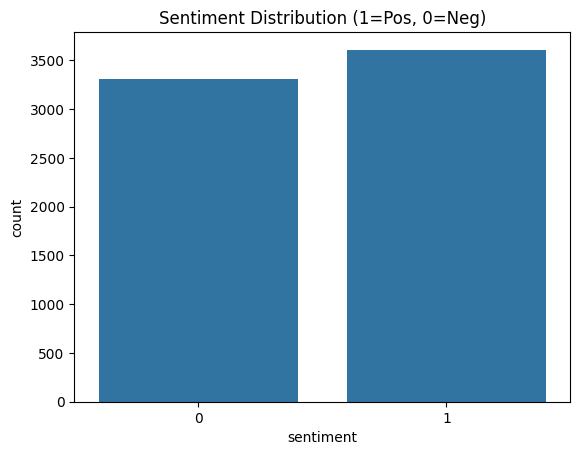


--- SVM (10-Fold CV Training) ---
Mean CV Accuracy: 0.7538
Final Test Report for SVM:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       912
           1       0.77      0.81      0.79       909

    accuracy                           0.79      1821
   macro avg       0.79      0.79      0.79      1821
weighted avg       0.79      0.79      0.79      1821


--- KNN (10-Fold CV Training) ---
Mean CV Accuracy: 0.5139
Final Test Report for KNN:
              precision    recall  f1-score   support

           0       0.52      0.69      0.59       912
           1       0.53      0.35      0.42       909

    accuracy                           0.52      1821
   macro avg       0.52      0.52      0.51      1821
weighted avg       0.52      0.52      0.51      1821


--- Decision Tree (10-Fold CV Training) ---
Mean CV Accuracy: 0.6441
Final Test Report for Decision Tree:
              precision    recall  f1-score   support

          

In [24]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, make_scorer, precision_score, recall_score, f1_score

# --- 1. Extraction ---
# Based on your sidebar screenshot, this is the exact name:
zip_filename = 'exercise05_datacollection-1 (2).zip'

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall('extracted_files')
    print(" Extraction complete.")
else:
    # If the name is slightly different, this will list what you actually have
    print(f" '{zip_filename}' not found. You have: {os.listdir('.')}")

# --- 2. Robust File Search ---
# This looks for the files anywhere inside 'extracted_files'
train_matches = glob.glob('extracted_files/**/stsa-train*', recursive=True)
test_matches = glob.glob('extracted_files/**/stsa-test*', recursive=True)

# Filter out Mac 'shadow' files if they exist
train_path = next((f for f in train_matches if '__MACOSX' not in f), None)
test_path = next((f for f in test_matches if '__MACOSX' not in f), None)

def load_data(path):
    with open(path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    data = []
    for line in lines:
        if len(line.strip()) > 2:
            data.append([int(line[0]), line[2:].strip()])
    return pd.DataFrame(data, columns=['sentiment', 'text'])

# --- 3. Execution ---
if train_path and test_path:
    print(f" Found Train at: {train_path}")
    print(f"Found Test at: {test_path}")

    train_df = load_data(train_path)
    test_df = load_data(test_path)

    # --- EDA ---
    print("\n--- EDA: Training Set Distribution ---")
    print(train_df['sentiment'].value_counts())
    sns.countplot(x='sentiment', data=train_df)
    plt.title('Sentiment Distribution (1=Pos, 0=Neg)')
    plt.show()

    # --- 80/20 Split & Vectorization ---
    X_train_full, X_val, y_train_full, y_val = train_test_split(
        train_df['text'], train_df['sentiment'], test_size=0.20, random_state=42
    )

    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
    X_train_tfidf = vectorizer.fit_transform(X_train_full)
    X_test_tfidf = vectorizer.transform(test_df['text'])

    # --- Models & 10-Fold CV ---
    models = {
        "SVM": SVC(kernel='linear'),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(n_estimators=100)
    }

    scoring = {'accuracy': 'accuracy', 'f1': 'f1'}

    for name, model in models.items():
        print(f"\n--- {name} (10-Fold CV Training) ---")
        cv_results = cross_validate(model, X_train_tfidf, y_train_full, cv=10, scoring=scoring)
        print(f"Mean CV Accuracy: {cv_results['test_accuracy'].mean():.4f}")

        # Train on full 80% and evaluate on Test set
        model.fit(X_train_tfidf, y_train_full)
        y_pred = model.predict(X_test_tfidf)
        print(f"Final Test Report for {name}:")
        print(classification_report(test_df['sentiment'], y_pred))
else:
    print("Critical Error: Could not find stsa-train or stsa-test inside the zip.")
    # Show what IS inside to help debug
    for root, dirs, files in os.walk('extracted_files'):
        for file in files:
            print(f"Found: {os.path.join(root, file)}")




## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


archive (4).zip extracted successfully.
 Loading data from: amazon_clustering_data/Amazon_Unlocked_Mobile.csv

--- EDA: Data Overview ---
Sample size: 3000 reviews


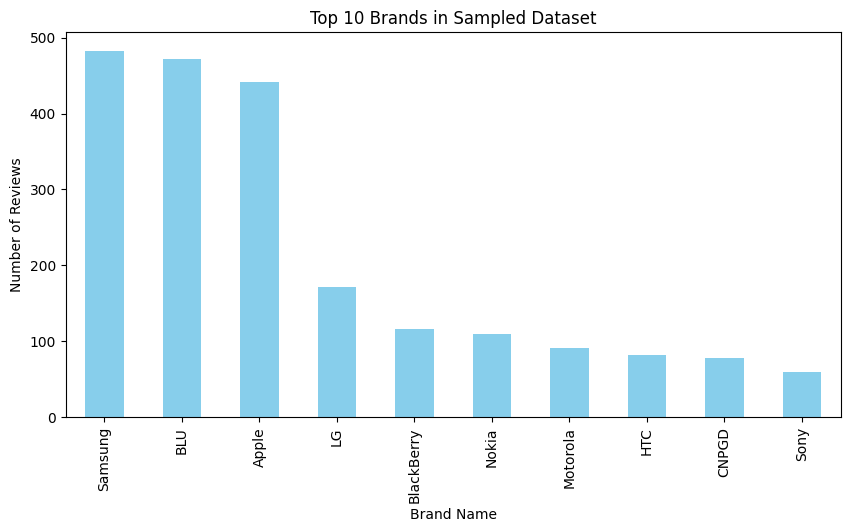

Computing clusters...


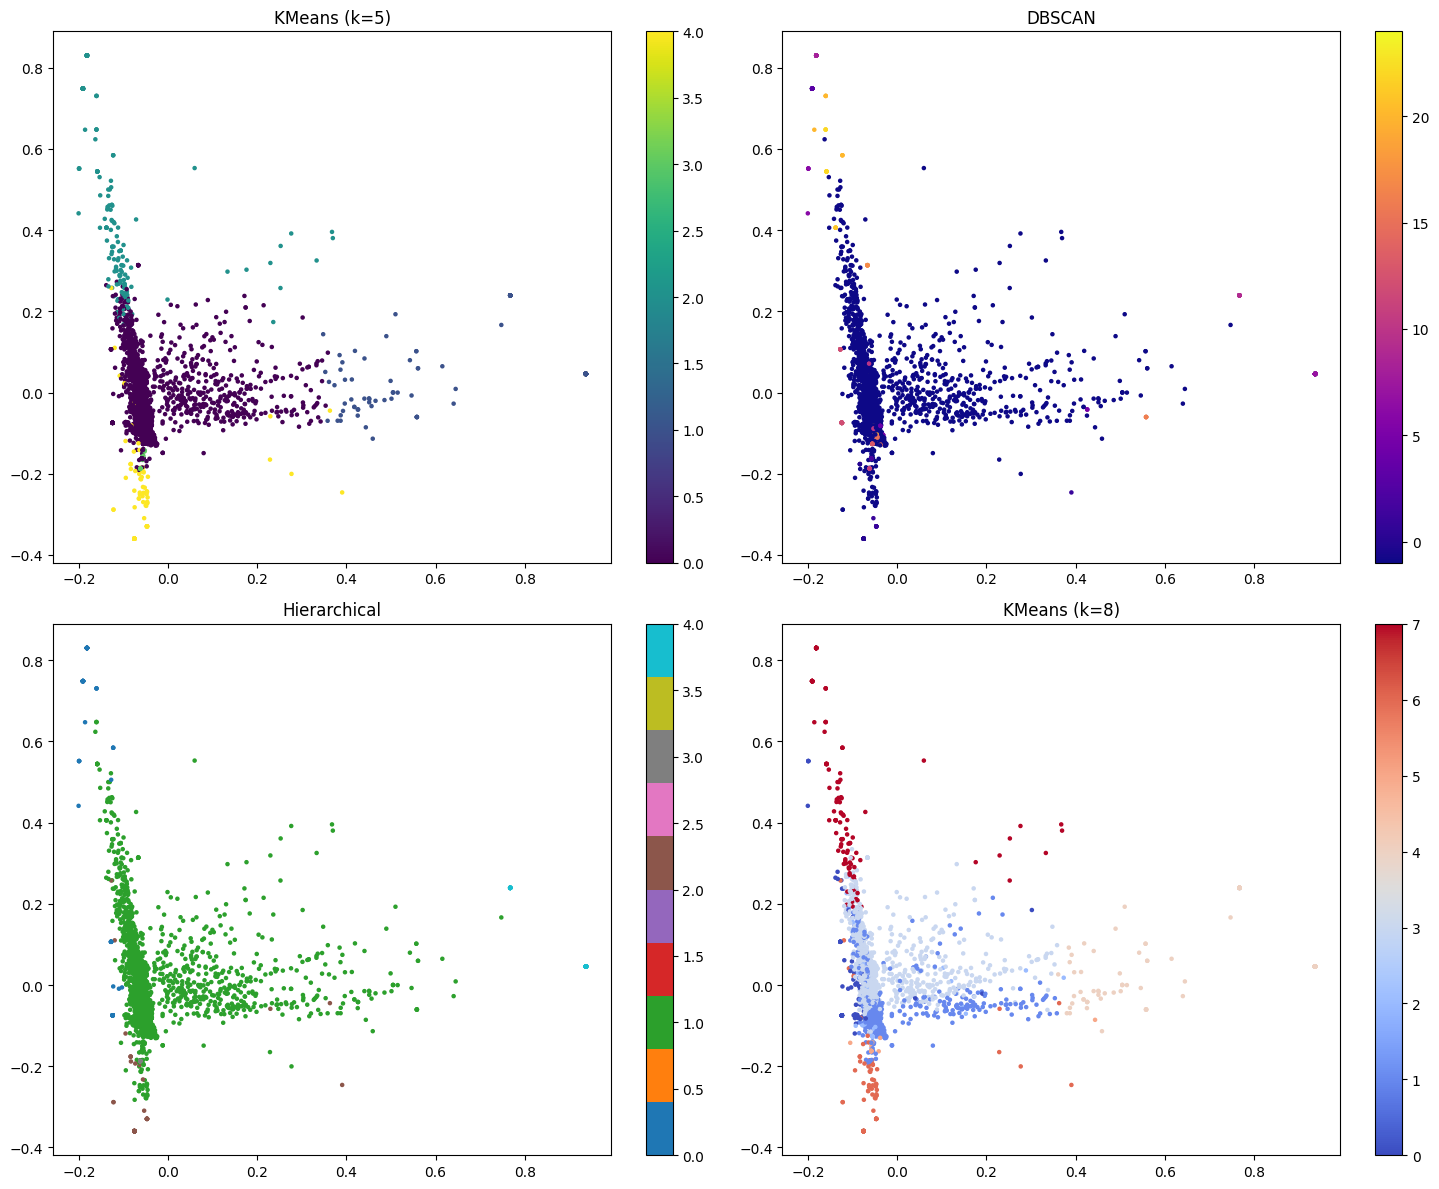

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# --- 1. Extraction & Discovery ---
zip_filename = 'archive (4).zip'

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall('amazon_clustering_data')
    print("archive (4).zip extracted successfully.")
else:
    print(f"ERROR: {zip_filename} not found in the sidebar.")

# Find the CSV file inside the extracted folders
csv_files = glob.glob("amazon_clustering_data/**/*.csv", recursive=True)

if not csv_files:
    print("ERROR: No CSV found inside the zip. Please check the file content.")
else:
    csv_path = csv_files[0]
    print(f" Loading data from: {csv_path}")

    # --- 2. Load & Sample Data ---
    # Using a subset of 3,000 rows to keep Hierarchical clustering fast
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=['Reviews'])
    df_sample = df.sample(3000, random_state=42).reset_index(drop=True)

    # --- 3. EDA ---
    print("\n--- EDA: Data Overview ---")
    print(f"Sample size: {df_sample.shape[0]} reviews")

    # Visualizing Top 10 Brands
    plt.figure(figsize=(10, 5))
    df_sample['Brand Name'].value_counts().head(10).plot(kind='bar', color='skyblue')
    plt.title('Top 10 Brands in Sampled Dataset')
    plt.ylabel('Number of Reviews')
    plt.show()

    # --- 4. Text Vectorization ---
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
    tfidf_matrix = tfidf.fit_transform(df_sample['Reviews'])
    tfidf_norm = normalize(tfidf_matrix)

    # Dimensionality reduction for visualization
    pca = PCA(n_components=2)
    coords = pca.fit_transform(tfidf_norm.toarray())

    # --- 5. Clustering (4 Methods) ---
    print("Computing clusters...")

    # Method 1: K-Means (5 clusters)
    km = KMeans(n_clusters=5, random_state=42, n_init=10)
    df_sample['KMeans'] = km.fit_predict(tfidf_norm)

    # Method 2: DBSCAN
    db = DBSCAN(eps=0.5, min_samples=5)
    df_sample['DBSCAN'] = db.fit_predict(tfidf_norm)

    # Method 3: Hierarchical (Agglomerative)
    hc = AgglomerativeClustering(n_clusters=5)
    df_sample['Hierarchical'] = hc.fit_predict(tfidf_norm.toarray())

    # Method 4: K-Means (8 clusters) - Alternative granularity
    km8 = KMeans(n_clusters=8, random_state=42, n_init=10)
    df_sample['KMeans_8'] = km8.fit_predict(tfidf_norm)

    # --- 6. Visualization ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    plot_params = [
        ('KMeans (k=5)', 'KMeans', 'viridis'),
        ('DBSCAN', 'DBSCAN', 'plasma'),
        ('Hierarchical', 'Hierarchical', 'tab10'),
        ('KMeans (k=8)', 'KMeans_8', 'coolwarm')
    ]

    for i, (title, label, cmap) in enumerate(plot_params):
        ax = axes.flatten()[i]
        scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df_sample[label], cmap=cmap, s=5)
        ax.set_title(title)
        fig.colorbar(scatter, ax=ax)

    plt.tight_layout()
    plt.show()

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**\The results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering are very different because they group text in different ways. When the data naturally forms clear, evenly sized groups, K-means works well and is quick. However, it has trouble with complex shapes. DBSCAN is better at finding clusters that aren't regular and can ignore noise. However, it might not find patterns if the data density changes. Hierarchical clustering is more flexible and shows relationships in a simple tree-like way, but it can take longer on big datasets. Word2Vec-based clustering gives better results because it captures the meanings of words. This means that similar works are grouped together in a more meaningful way than with basic methods.


# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

